# 🧨 Research-paper replication: risk-managed momentum

## 🧭 tl;dr

Momentum has historically earned strong average returns but can crash when a bear market is followed by a sharp rebound. Barroso and Santa-Clara’s **Momentum Has Its Moments** and Daniel and Moskowitz’s **Momentum Crashes** study volatility-aware ways to reduce this risk. This notebook builds a transparent ETF proxy: long recent winners, short recent losers, then scale the portfolio down when its own realized volatility rises.

> Educational research only. Not financial advice. This is a simplified ETF implementation, not a stock-level replication of either paper.

<div style="border-left: 5px solid #DC2626; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #FEF2F2; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>First inspect plain momentum. Then compare the volatility-managed version and the crisis windows. The point is to see whether risk control improves the path, not to optimize a single Sharpe ratio.</div>


## 📚 Papers and research question

- [Barroso and Santa-Clara, *Momentum Has Its Moments*](https://doi.org/10.1016/j.jfineco.2014.11.010) argue that momentum volatility is time-varying and can be managed with volatility scaling.
- [Daniel and Moskowitz, *Momentum Crashes*](https://www.nber.org/papers/w20439) show that crashes occur especially after market declines and during high-volatility rebounds, and propose dynamic risk management.

The original papers use broad stock universes and carefully constructed factor portfolios. This notebook uses liquid ETFs as a teaching proxy.

**Research question:** does scaling a long-short ETF momentum sleeve toward a 12% annualized volatility target reduce drawdowns and momentum-crash losses relative to unscaled momentum?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_momentum_panel():
    tickers = ["SPY", "EFA", "EEM", "TLT", "IEF", "LQD", "GLD", "DBC", "VNQ", "XLE", "XLK", "XLF"]
    try:
        panel = load_price_panel(tickers, "2006-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily ETF closes"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=5_000, seed=808, start="2006-01-01")["close"]
        panel = pd.DataFrame({ticker: demo * (1.0 + 0.02 * i) for i, ticker in enumerate(tickers)}, index=demo.index)
        source = f"deterministic demo ETF panel fallback ({type(exc).__name__})"
    return panel.dropna(), source


close, data_source = load_momentum_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,008 | 2006-02-06 to 2025-12-31


,DBC,EEM,EFA,GLD,IEF,LQD,SPY,TLT,VNQ,XLE,XLF,XLK
Date,,,,,,,,,,,,
2006-02-06,19.185099,21.803118,33.987099,56.720001,48.517384,47.331615,86.932251,47.462032,27.023006,15.481529,17.145823,8.176649
2006-02-07,18.630157,21.231091,33.735306,54.599998,48.458858,47.212311,86.163208,47.237831,26.810507,14.835320,17.032133,8.153529
2006-02-08,18.550880,21.297092,33.855728,54.830002,48.429638,47.212311,86.945992,47.128334,26.691498,14.838070,17.140413,8.311514
2006-02-09,18.725290,21.352095,33.921413,56.180000,48.476437,47.287453,86.801788,47.342117,26.818998,14.499841,17.183729,8.272983
2006-02-10,18.384398,21.319094,33.844776,54.790001,48.336014,47.199081,86.959709,47.081451,26.844494,14.447601,17.281172,8.338486


## 📜 Strategy rules

### Plain cross-sectional momentum

At each month start, compute each ETF’s prior 12–1 month return: a 252-day return with the most recent 21 trading days skipped. Go long the top three ETFs and short the bottom three, with total long exposure of 0.50 and total short exposure of −0.50.

### Volatility-managed momentum

Estimate the plain momentum sleeve’s trailing 126-day annualized volatility using only information available before the next rebalance. Scale the long-short weights by `min(1, 12% / estimated volatility)`. This implementation only de-leverages because the shared portfolio engine caps absolute gross exposure at 1.0; the original papers also study leverage in low-volatility states.


In [3]:

def cross_sectional_momentum_weights(close, lookback=252, skip_recent=21, top_n=3):
    score = close.shift(skip_recent).pct_change(lookback)
    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        valid = score.loc[timestamp].dropna()
        if len(valid) < 2 * top_n:
            continue
        winners = valid.nlargest(top_n).index
        losers = valid.nsmallest(top_n).index
        candidates.loc[timestamp, winners] = 0.5 / top_n
        candidates.loc[timestamp, losers] = -0.5 / top_n
    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    return weights.ffill().fillna(0.0)


base_weights = cross_sectional_momentum_weights(close)
base_zero_cost = run_portfolio_backtest(close, base_weights, transaction_cost_bps=0.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
trailing_vol = base_zero_cost.frame["net_returns"].rolling(126, min_periods=63).std().shift(1) * np.sqrt(252)
scale = (0.12 / trailing_vol).clip(lower=0.0, upper=1.0).fillna(0.0)
managed_weights = base_weights.mul(scale, axis=0)

plain = run_portfolio_backtest(close, base_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
managed = run_portfolio_backtest(close, managed_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
spy_hold = run_portfolio_backtest(close, pd.DataFrame({"SPY": 1.0, **{c: 0.0 for c in close.columns if c != "SPY"}}, index=close.index), transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits = split_time_series(close)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results: unscaled versus risk-managed momentum

The default test charges 10 bps per unit of portfolio turnover. Sharpe uses daily portfolio returns, including periods when the volatility-managed sleeve is de-levered or in cash.


In [4]:

rows=[]
for name, backtest in [("Plain momentum", plain), ("Volatility-managed momentum", managed), ("SPY buy & hold", spy_hold)]:
    for period_name, period_index in periods.items():
        metrics=metrics_for_period(backtest, period_index)
        rows.append({"strategy":name,"period":period_name,**metrics})
summary=pd.DataFrame(rows).set_index(["strategy","period"])
display(summary[["annualized_return","annualized_volatility","sharpe_ratio","sortino_ratio","max_drawdown","calmar_ratio","annualized_turnover","number_of_trades","total_return_after_costs"]].style.format({"annualized_return":"{:.2%}","annualized_volatility":"{:.2%}","sharpe_ratio":"{:.2f}","sortino_ratio":"{:.2f}","max_drawdown":"{:.2%}","calmar_ratio":"{:.2f}","annualized_turnover":"{:.2f}","number_of_trades":"{:.0f}","total_return_after_costs":"{:.2%}"}))


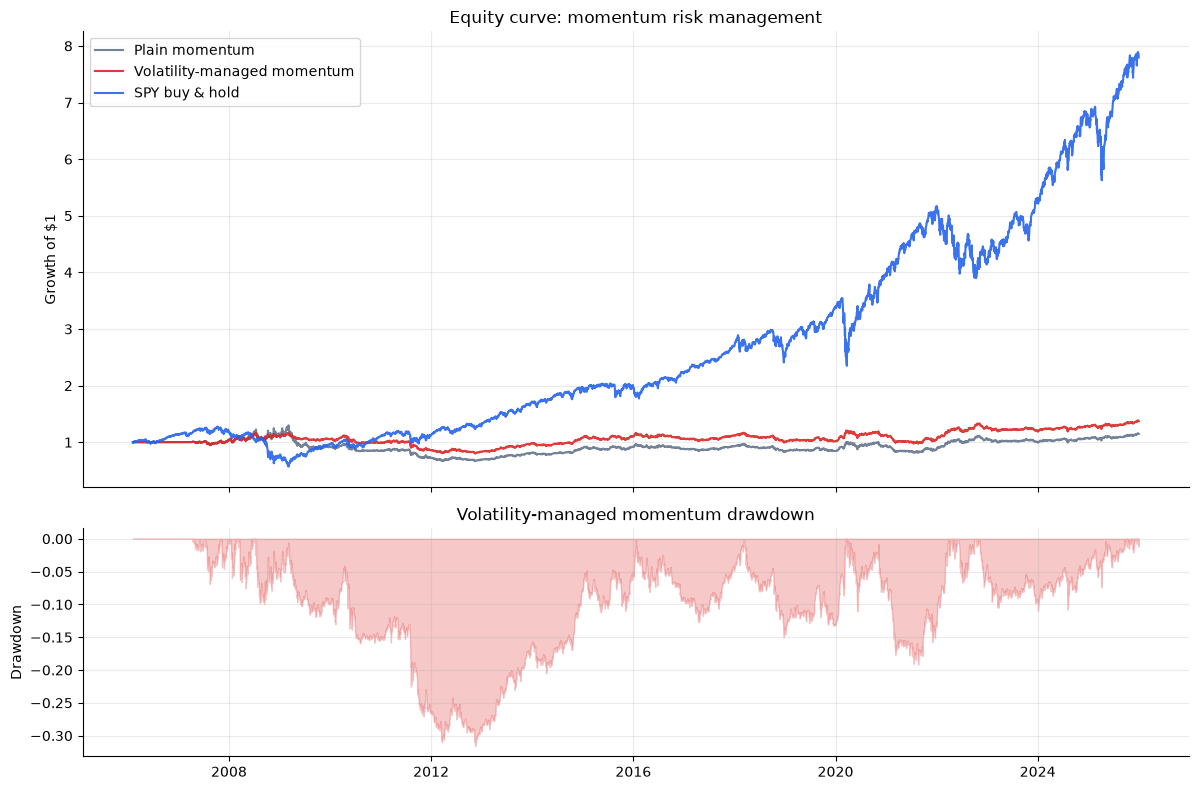

In [5]:

fig, axes=plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={"height_ratios":[2,1]})
for backtest,label,color in [(plain,"Plain momentum","#64748B"),(managed,"Volatility-managed momentum","#DC2626"),(spy_hold,"SPY buy & hold","#2563EB")]:
    axes[0].plot(backtest.frame.index, backtest.frame.equity/backtest.frame.equity.iloc[0], label=label, color=color, alpha=0.9)
axes[0].set_title("Equity curve: momentum risk management")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(managed.frame.index, managed.frame.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("Volatility-managed momentum drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧯 Momentum-crash stress windows

These are descriptive windows selected because the papers emphasize crash and rebound states. They are not used to choose parameters.


In [6]:

stress_windows={"2008 crisis":"2008-01-01/2009-12-31","2020 rebound":"2020-02-01/2020-06-30","2022 inflation":"2022-01-01/2022-12-31"}
stress_rows=[]
for label,window in stress_windows.items():
    start,end=window.split("/")
    index=close.loc[start:end].index
    for name,backtest in [("Plain momentum",plain),("Volatility-managed momentum",managed),("SPY buy & hold",spy_hold)]:
        metrics=metrics_for_period(backtest,index)
        stress_rows.append({"window":label,"strategy":name,"return":metrics["total_return_after_costs"],"sharpe":metrics["sharpe_ratio"],"drawdown":metrics["max_drawdown"]})
display(pd.DataFrame(stress_rows).style.format({"return":"{:.2%}","sharpe":"{:.2f}","drawdown":"{:.2%}"}))


,window,strategy,return,sharpe,drawdown
0,2008 crisis,Plain momentum,-11.54%,-0.08,-32.39%
1,2008 crisis,Volatility-managed momentum,2.13%,0.15,-11.88%
2,2008 crisis,SPY buy & hold,-20.14%,-0.15,-51.87%
3,2020 rebound,Plain momentum,3.93%,0.61,-12.67%
4,2020 rebound,Volatility-managed momentum,4.17%,0.68,-11.04%
5,2020 rebound,SPY buy & hold,-3.17%,0.08,-33.72%
6,2022 inflation,Plain momentum,22.96%,2.03,-7.39%
7,2022 inflation,Volatility-managed momentum,22.69%,2.02,-7.39%
8,2022 inflation,SPY buy & hold,-18.18%,-0.71,-24.50%


In [7]:

scale_summary=pd.Series({"average_scale":scale.loc[periods["test"]].mean(),"median_scale":scale.loc[periods["test"]].median(),"fraction_delevered":(scale.loc[periods["test"]]<0.999).mean()})
display(scale_summary.to_frame("value").style.format("{:.2%}"))


,value
average_scale,99.91%
median_scale,100.00%
fraction_delevered,4.19%


## ⚖️ What went well / what went wrong

### ✅ What went well

- The notebook turns a well-known paper idea into an inspectable sequence: momentum signal, realized volatility estimate, and position scaling.
- The stress windows make the key economic claim visible: volatility management can change the path during rebounds and crises.
- The plain strategy, managed strategy, and SPY benchmark use the same assets, dates, costs, and execution delay.

### ⚠️ What went wrong or remains uncertain

- The ETF universe is small and contains asset classes, not the paper’s broad stock universe.
- The shared engine caps gross exposure at one, so this is de-risking rather than the full leveraged constant-target-volatility implementation.
- The volatility estimate is based on the strategy’s own proxy returns; different formation horizons and forecasting models can materially change the result.
- Crisis windows are retrospective diagnostics, not independent evidence.

**Bottom line:** volatility scaling is a risk-control hypothesis, not a free Sharpe upgrade. Its value should be judged by out-of-sample drawdown and crash behavior after costs.
